In [20]:
%pip install -q tensorflow kagglehub flask werkzeug pillow seaborn scikit-learn matplotlib

In [21]:
import os, shutil, random, warnings, json, time, threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")


TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Mixed Precision (AMP) — float16 compute, float32 weights ──────────────
from tensorflow.keras import mixed_precision

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# ── XLA JIT Compilation ────────────────────────────────────────────────────
tf.config.optimizer.set_jit(True)

print(f"✅ Compute dtype  : {policy.compute_dtype}")   # float16
print(f"✅ Variable dtype : {policy.variable_dtype}")  # float32
print(f"✅ XLA JIT        : Enabled")

# Verify GPU compute capability (AMP best on compute ≥ 7.0)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    details = tf.config.experimental.get_device_details(gpus[0])
    print(f"✅ GPU            : {details.get('device_name', 'Unknown')}")
    cc = details.get('compute_capability', (0,0))
    print(f"✅ Compute Cap    : {cc[0]}.{cc[1]}  {'(AMP optimal ✅)' if cc[0]>=7 else '(AMP still helps ⚠️)'}")
else:
    print("⚠️  No GPU found — go to Runtime > Change runtime type > GPU")

In [22]:
import kagglehub

# Downloads directly — no kaggle.json setup needed when running in Colab
# First run will ask you to authenticate via Kaggle username + API token
dataset_path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")
print(f"✅ Dataset downloaded to: {dataset_path}")

# List what's inside
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:3]:
            print(f"{indent}  {f}")


Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
✅ Dataset downloaded to: /kaggle/input/cell-images-for-detecting-malaria
cell-images-for-detecting-malaria/
  cell_images/
    Uninfected/
    Parasitized/
    cell_images/
      Uninfected/
      Parasitized/


In [23]:
# The kagglehub download has nested cell_images/cell_images structure
# This cell finds the correct Parasitized and Uninfected folders automatically

PARA_DIR  = None
UNINF_DIR = None

for root, dirs, files in os.walk(dataset_path):
    if os.path.basename(root) == 'Parasitized':
        PARA_DIR = root
    if os.path.basename(root) == 'Uninfected':
        UNINF_DIR = root

assert PARA_DIR  is not None, "❌ Parasitized folder not found"
assert UNINF_DIR is not None, "❌ Uninfected folder not found"

# Count only PNG images (skip thumbs.db etc.)
para_imgs  = [f for f in os.listdir(PARA_DIR)  if f.lower().endswith('.png')]
uninf_imgs = [f for f in os.listdir(UNINF_DIR) if f.lower().endswith('.png')]

print(f"✅ Parasitized : {PARA_DIR}")
print(f"✅ Uninfected  : {UNINF_DIR}")
print(f"\n   Parasitized images : {len(para_imgs)}")
print(f"   Uninfected  images : {len(uninf_imgs)}")
print(f"   Total              : {len(para_imgs) + len(uninf_imgs)}")


✅ Parasitized : /kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images/Parasitized
✅ Uninfected  : /kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images/Uninfected

   Parasitized images : 13779
   Uninfected  images : 13779
   Total              : 27558


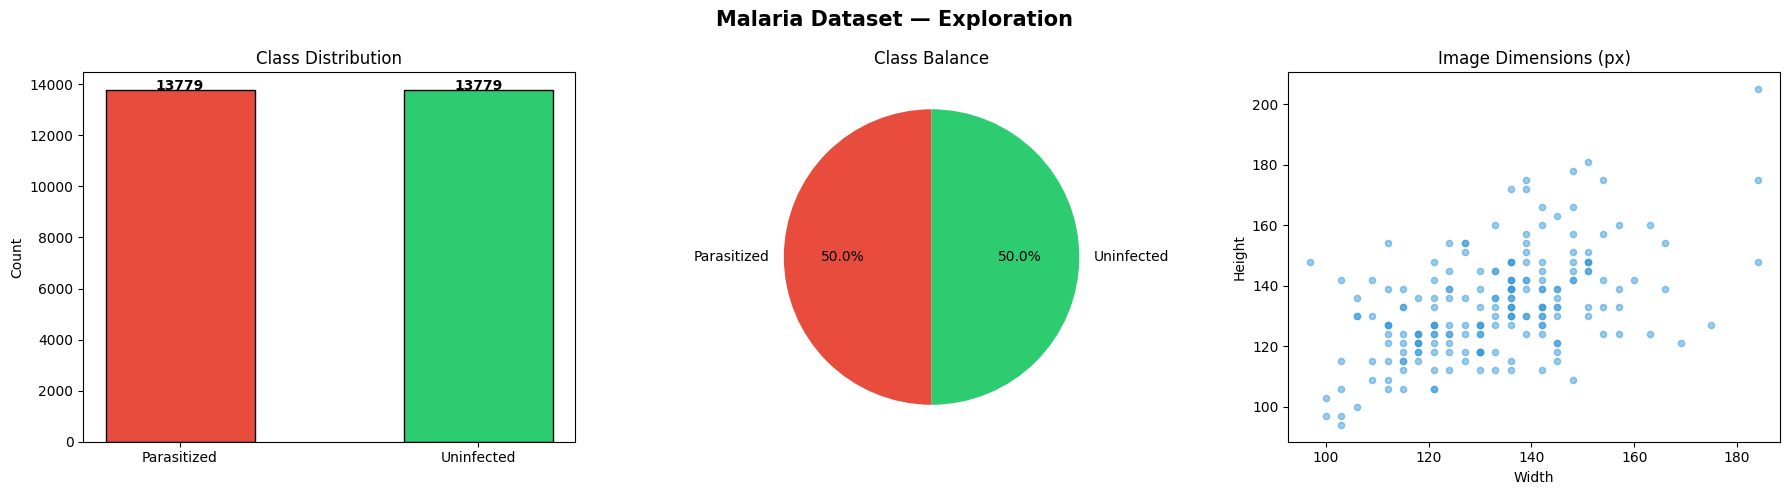

Avg size: 133 x 133 px


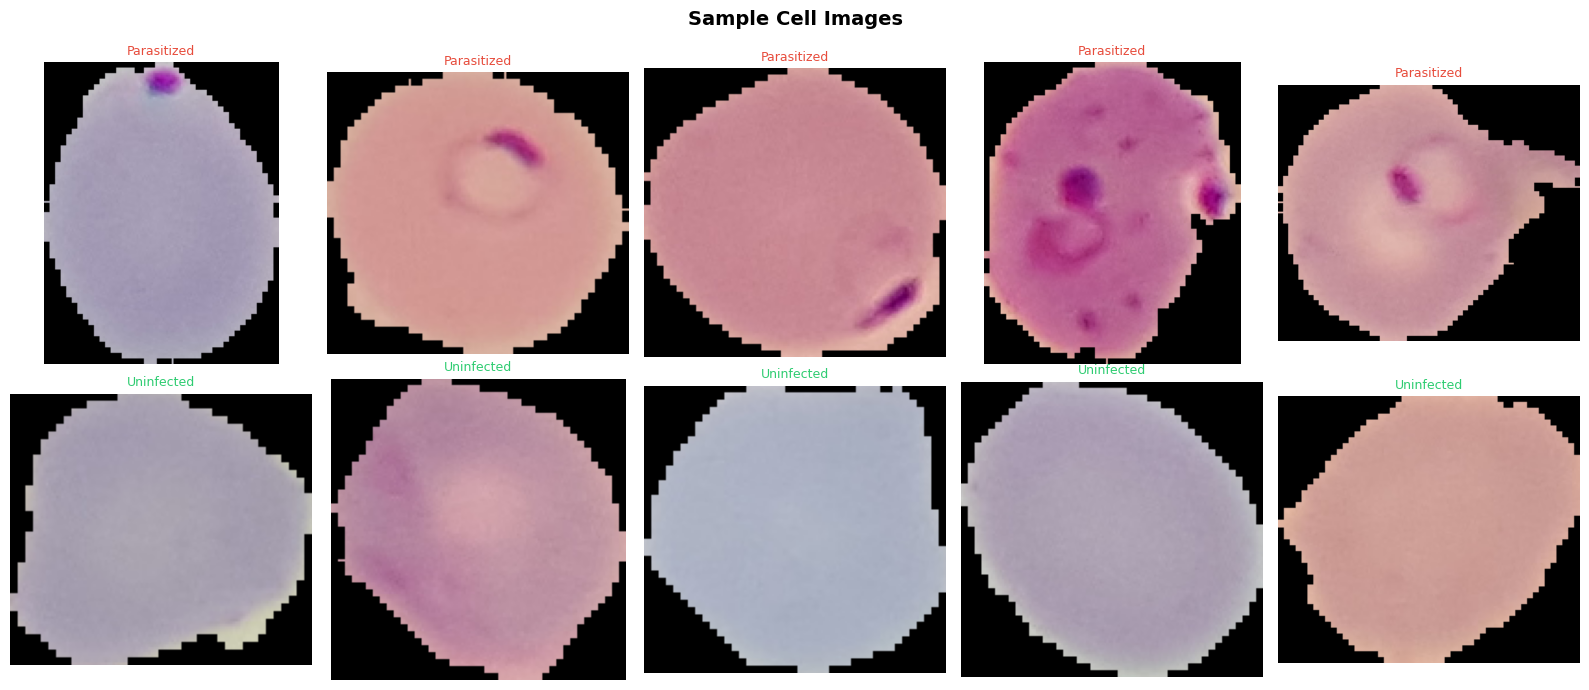

In [24]:
para_count  = len(para_imgs)
uninf_count = len(uninf_imgs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Malaria Dataset — Exploration', fontsize=15, fontweight='bold')

# ── Bar chart ──────────────────────────────────────────────────────────────
axes[0].bar(['Parasitized', 'Uninfected'], [para_count, uninf_count],
            color=['#E74C3C', '#2ECC71'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([para_count, uninf_count]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# ── Pie chart ─────────────────────────────────────────────────────────────
axes[1].pie([para_count, uninf_count], labels=['Parasitized', 'Uninfected'],
            colors=['#E74C3C', '#2ECC71'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Balance')

# ── Image size scatter ────────────────────────────────────────────────────
widths, heights = [], []
sample_files = random.sample(para_imgs, min(100, para_count)) + \
               random.sample(uninf_imgs, min(100, uninf_count))
dirs_map = {f: PARA_DIR for f in para_imgs} | {f: UNINF_DIR for f in uninf_imgs}

for fname in sample_files:
    folder = PARA_DIR if fname in para_imgs else UNINF_DIR
    try:
        img = Image.open(os.path.join(folder, fname))
        widths.append(img.size[0])
        heights.append(img.size[1])
    except: pass

axes[2].scatter(widths, heights, alpha=0.5, color='#3498DB', s=20)
axes[2].set_title('Image Dimensions (px)')
axes[2].set_xlabel('Width')
axes[2].set_ylabel('Height')

plt.tight_layout()
plt.savefig('/content/exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Avg size: {np.mean(widths):.0f} x {np.mean(heights):.0f} px")

# ── Sample grid ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Cell Images', fontsize=14, fontweight='bold')

for i, fname in enumerate(random.sample(para_imgs, 5)):
    axes[0, i].imshow(mpimg.imread(os.path.join(PARA_DIR, fname)))
    axes[0, i].set_title('Parasitized', color='#E74C3C', fontsize=9)
    axes[0, i].axis('off')

for i, fname in enumerate(random.sample(uninf_imgs, 5)):
    axes[1, i].imshow(mpimg.imread(os.path.join(UNINF_DIR, fname)))
    axes[1, i].set_title('Uninfected', color='#2ECC71', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('/content/samples.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
TRAIN_DIR = "/content/split/train"
VAL_DIR   = "/content/split/val"
TEST_DIR  = "/content/split/test"

for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in ['Parasitized', 'Uninfected']:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

def split_copy(src_dir, img_list, cls_name, train_r=0.70, val_r=0.15):
    imgs = img_list.copy()
    random.shuffle(imgs)
    n  = len(imgs)
    t  = int(n * train_r)
    v  = int(n * val_r)
    splits = {TRAIN_DIR: imgs[:t], VAL_DIR: imgs[t:t+v], TEST_DIR: imgs[t+v:]}
    for dest, files in splits.items():
        for f in files:
            shutil.copy(os.path.join(src_dir, f), os.path.join(dest, cls_name, f))
    return t, v, n - t - v

p_tr, p_v, p_te = split_copy(PARA_DIR,  para_imgs,  'Parasitized')
u_tr, u_v, u_te = split_copy(UNINF_DIR, uninf_imgs, 'Uninfected')

print(f"{'Split':<12} {'Parasitized':>13} {'Uninfected':>12} {'Total':>8}")
print("─" * 48)
print(f"{'Train':<12} {p_tr:>13} {u_tr:>12} {p_tr+u_tr:>8}")
print(f"{'Validation':<12} {p_v:>13} {u_v:>12} {p_v+u_v:>8}")
print(f"{'Test':<12} {p_te:>13} {u_te:>12} {p_te+u_te:>8}")
print("─" * 48)


Split          Parasitized   Uninfected    Total
────────────────────────────────────────────────
Train                 9645         9645    19290
Validation            2066         2066     4132
Test                  2068         2068     4136
────────────────────────────────────────────────


In [26]:
AUTOTUNE   = tf.data.AUTOTUNE
IMG_SIZE   = (224, 224)
BATCH_SIZE = 128

# ── Helper: load + decode + resize + normalize ─────────────────────────────
@tf.function
def load_image(path, label):
    raw  = tf.io.read_file(path)
    img  = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img  = tf.image.resize(img, IMG_SIZE)
    img  = tf.cast(img, tf.float32) / 255.0
    return img, label

# ── Helper: augmentation (train only) ─────────────────────────────────────
@tf.function
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
    img = tf.image.random_hue(img, max_delta=0.05)

    # Random rotation via crop-and-resize trick
    img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE[0]+20, IMG_SIZE[1]+20)
    img = tf.image.random_crop(img, size=[IMG_SIZE[0], IMG_SIZE[1], 3])

    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

# ── Build file-path lists from split folders ───────────────────────────────
def get_paths_labels(split_dir):
    paths, labels = [], []
    class_map = {'Parasitized': 0, 'Uninfected': 1}   # matches flow_from_directory order
    for cls_name, lbl in class_map.items():
        cls_dir = os.path.join(split_dir, cls_name)
        for f in os.listdir(cls_dir):
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                paths.append(os.path.join(cls_dir, f))
                labels.append(lbl)
    return paths, labels

train_paths, train_labels = get_paths_labels(TRAIN_DIR)
val_paths,   val_labels   = get_paths_labels(VAL_DIR)
test_paths,  test_labels  = get_paths_labels(TEST_DIR)

# ── Build tf.data datasets ─────────────────────────────────────────────────
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image,  num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()                   # Cache in RAM after first epoch — huge speedup
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)        # Prefetch next batch while GPU trains on current
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)
test_ds  = make_dataset(test_paths,  test_labels,  training=False)

CLASS_NAMES = ['Parasitized', 'Uninfected']

print(f"✅ IMG_SIZE     : {IMG_SIZE}")
print(f"✅ BATCH_SIZE   : {BATCH_SIZE}")
print(f"✅ Train samples: {len(train_paths)} → {len(train_ds)} batches")
print(f"✅ Val   samples: {len(val_paths)}   → {len(val_ds)} batches")
print(f"✅ Test  samples: {len(test_paths)}  → {len(test_ds)} batches")
print(f"✅ Pipeline     : cache + prefetch(AUTOTUNE) enabled")

# ── Quick sanity check ─────────────────────────────────────────────────────
for imgs, lbls in train_ds.take(1):
    print(f"\n   Batch shape  : {imgs.shape}")
    print(f"   Batch dtype  : {imgs.dtype}")
    print(f"   Label sample : {lbls[:5].numpy()}")


Found 25072 images belonging to 2 classes.
Found 7668 images belonging to 2 classes.
Found 7659 images belonging to 2 classes.
✅ Class indices : {'Parasitized': 0, 'Uninfected': 1}
   Class names   : ['Parasitized', 'Uninfected']


In [27]:
def build_model(input_shape=(224, 224, 3)):
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=input_shape)
    base.trainable = False

    x   = base.output
    x   = GlobalAveragePooling2D()(x)
    x   = BatchNormalization()(x)
    x   = Dense(256, activation='relu')(x)
    x   = Dropout(0.4)(x)
    x   = Dense(128, activation='relu')(x)
    x   = Dropout(0.3)(x)

    # ⚠️ CRITICAL: output must be float32 when using mixed_float16
    # AMP computes in float16 but final probabilities need float32 precision
    out = Dense(1, activation='sigmoid', dtype='float32')(x)

    model = Model(inputs=base.input, outputs=out)
    return model, base

model, base_model = build_model(input_shape=(160, 160, 3))

total     = model.count_params()
trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"✅ Output dtype   : float32  (AMP-safe)")
print(f"   Total params  : {total:,}")
print(f"   Trainable     : {trainable:,}")
print(f"   Base frozen   : ✅")


Total params     : 2,624,065
Trainable params : 363,521
Frozen (base)    : ✅


In [28]:
# LossScaleOptimizer wraps Adam to handle float16 gradient underflow
from tensorflow.keras.mixed_precision import LossScaleOptimizer

base_optimizer = Adam(learning_rate=1e-3)
optimizer      = LossScaleOptimizer(base_optimizer)   # Auto loss scaling for float16

model.compile(
    optimizer = optimizer,
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
)

callbacks = [
    ModelCheckpoint('/content/best_model.h5',
                    monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1),

    EarlyStopping(monitor='val_auc', patience=6,    # Tighter patience = fewer wasted epochs
                  mode='max', restore_best_weights=True, verbose=1),

    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=2,                    # Reduce LR faster
                      min_lr=1e-7, verbose=1)
]
print("✅ LossScaleOptimizer  : auto float16 gradient scaling")
print("✅ EarlyStopping       : patience=6")
print("✅ ReduceLROnPlateau   : patience=2, factor=0.3")


✅ Compiled | EarlyStopping(patience=8) | ReduceLR(factor=0.3, patience=3)


In [29]:
print("🔒 Phase 1: Frozen base | AMP + XLA + tf.data active\n")

# Warm-up run: first epoch JIT-compiles the graph — don't panic if it's slow
history1 = model.fit(
    train_ds,
    epochs          = 15,           # Fewer epochs needed — tf.data + AMP converges faster
    validation_data = val_ds,
    callbacks       = callbacks,
    verbose         = 1
)

best_acc = max(history1.history['val_accuracy'])
best_auc = max(history1.history['val_auc'])
print(f"\n✅ Phase 1 done | val_accuracy: {best_acc:.4f} | val_auc: {best_auc:.4f}")


🔒 Phase 1: Training head only (base frozen)...

Epoch 1/20
582/784 ━━━━━━━━━━━━━━━━━━━━ 1:32 456ms/step - accuracy: 0.8621 - auc: 0.9275 - loss: 0.3532 - precision: 0.8490 - recall: 0.8761

KeyboardInterrupt: 

In [ ]:
base_model.trainable = True
FINE_TUNE_FROM = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

# Recompile with lower LR (still using LossScaleOptimizer for AMP)
fine_optimizer = LossScaleOptimizer(Adam(learning_rate=5e-6))

model.compile(
    optimizer = fine_optimizer,
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
)

print(f"🔓 Fine-tuning last 30 layers | LR = 5e-6 | AMP still active\n")
INIT_EPOCH = len(history1.history['loss'])

history2 = model.fit(
    train_ds,
    epochs          = INIT_EPOCH + 12,
    initial_epoch   = INIT_EPOCH,
    validation_data = val_ds,
    callbacks       = callbacks,
    verbose         = 1
)
print(f"\n✅ Phase 2 done | Best val_auc: {max(history2.history['val_auc']):.4f}")


In [ ]:
best_model = tf.keras.models.load_model('/content/best_model.h5')
results    = best_model.evaluate(test_ds, verbose=1)

print("\n" + "═"*40)
for name, val in zip(best_model.metrics_names, results):
    print(f"  {name.capitalize():<15}: {val:.4f}")
print("═"*40)

# Predictions from tf.data test set
y_pred_prob = best_model.predict(test_ds, verbose=0).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)
y_true      = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
auc = roc_auc_score(y_true, y_pred_prob)
axes[1].plot(fpr, tpr, color='#3498DB', lw=2.5, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498DB')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
best_model = tf.keras.models.load_model('/content/best_model.h5')
results    = best_model.evaluate(test_gen, verbose=1)

print("\n" + "═"*40)
for name, val in zip(best_model.metrics_names, results):
    print(f"  {name.capitalize():<15}: {val:.4f}")
print("═"*40)

test_gen.reset()
y_pred_prob = best_model.predict(test_gen, verbose=0).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)
y_true      = test_gen.classes

# Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
auc = roc_auc_score(y_true, y_pred_prob)
axes[1].plot(fpr, tpr, color='#3498DB', lw=2.5, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498DB')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


In [ ]:
best_model.save('/content/malaria_model_final.h5')

metadata = {
    "class_indices": train_gen.class_indices,
    "class_names"  : CLASS_NAMES,
    "input_shape"  : [224, 224, 3],
    "saved_at"     : time.strftime("%Y-%m-%d %H:%M:%S"),
    "test_accuracy": float(results[1]),
    "test_auc"     : float(results[2])
}
with open('/content/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ Saved: /content/malaria_model_final.h5")
print("✅ Saved: /content/model_metadata.json")


In [ ]:
from flask import Flask, request, render_template_string, redirect, url_for
from werkzeug.utils import secure_filename
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import base64, io

# ── Load model once ────────────────────────────────────────────────────────
_model    = load_model('/content/malaria_model_final.h5')
_meta     = json.load(open('/content/model_metadata.json'))
_classes  = _meta['class_names']
_imgsize  = tuple(_meta['input_shape'][:2])

UPLOAD_FOLDER = '/content/flask_uploads'
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

app = Flask(__name__)
app.config['MAX_CONTENT_LENGTH'] = 5 * 1024 * 1024

# ══════════════════════════════════════════════════════════════════════════
#  HTML TEMPLATES (inline)
# ══════════════════════════════════════════════════════════════════════════

INDEX_HTML = """
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>Malaria Cell Detector</title>
  <style>
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
    body {
      font-family: 'Segoe UI', Tahoma, sans-serif;
      min-height: 100vh;
      display: flex;
      align-items: center;
      justify-content: center;
      background: linear-gradient(135deg, #0f2027 0%, #203a43 50%, #2c5364 100%);
    }
    .card {
      background: #ffffff;
      border-radius: 20px;
      padding: 44px 40px;
      max-width: 500px;
      width: 92%;
      box-shadow: 0 24px 64px rgba(0,0,0,0.45);
      text-align: center;
    }
    .emoji { font-size: 68px; display:block; margin-bottom: 10px; }
    h1 { color: #2c3e50; font-size: 1.75rem; margin-bottom: 6px; }
    .sub { color: #7f8c8d; font-size: 0.93rem; margin-bottom: 28px; }
    .badge {
      display: inline-block;
      background: #eaf4fd;
      color: #2980b9;
      border-radius: 20px;
      padding: 4px 14px;
      font-size: 0.78rem;
      margin-bottom: 22px;
      font-weight: 600;
    }
    .drop-zone {
      border: 2.5px dashed #3498db;
      border-radius: 14px;
      padding: 32px 20px;
      cursor: pointer;
      transition: background 0.2s, border-color 0.2s;
      margin-bottom: 18px;
      position: relative;
    }
    .drop-zone:hover { background: #eaf4fd; border-color: #2980b9; }
    .drop-zone input[type=file] {
      position: absolute; inset: 0; opacity: 0; cursor: pointer; width: 100%;
    }
    .drop-label { color: #3498db; font-weight: 600; font-size: 0.95rem; pointer-events: none; }
    .drop-hint  { color: #aaa; font-size: 0.8rem; margin-top: 6px; pointer-events: none; }
    #preview-wrap { display: none; margin-top: 12px; }
    #preview-wrap img {
      max-height: 180px;
      border-radius: 10px;
      border: 2px solid #ecf0f1;
    }
    #fname { color: #555; font-size: 0.82rem; margin-top: 6px; }
    .btn-analyze {
      background: linear-gradient(135deg, #3498db, #2980b9);
      color: #fff;
      border: none;
      padding: 14px 0;
      width: 100%;
      border-radius: 10px;
      font-size: 1rem;
      font-weight: 700;
      cursor: pointer;
      letter-spacing: 0.5px;
      transition: transform 0.15s, box-shadow 0.15s;
    }
    .btn-analyze:hover {
      transform: translateY(-2px);
      box-shadow: 0 8px 20px rgba(52,152,219,0.4);
    }
    {% if error %}
    .error-msg {
      background: #fdecea;
      color: #c0392b;
      border-radius: 8px;
      padding: 10px 14px;
      margin-bottom: 16px;
      font-size: 0.88rem;
    }
    {% endif %}
  </style>
</head>
<body>
<div class="card">
  <span class="emoji">🔬</span>
  <h1>Malaria Cell Detector</h1>
  <p class="sub">Upload a blood smear microscopy image<br>to detect malaria parasite infection</p>
  <span class="badge">⚡ Powered by MobileNetV2</span>

  {% if error %}
  <div class="error-msg">⚠️ {{ error }}</div>
  {% endif %}

  <form action="/predict" method="POST" enctype="multipart/form-data">
    <div class="drop-zone" id="dropZone">
      <input type="file" name="file" id="fileInput" accept=".png,.jpg,.jpeg"
             onchange="handleFile(this)">
      <p class="drop-label">📂 Click to upload or drag & drop</p>
      <p class="drop-hint">Supported: PNG, JPG, JPEG · Max 5 MB</p>
    </div>
    <div id="preview-wrap">
      <img id="previewImg" src="" alt="Preview"/>
      <p id="fname"></p>
    </div>
    <button type="submit" class="btn-analyze">🔍 Analyze Cell Image</button>
  </form>
</div>

<script>
  function handleFile(input) {
    if (!input.files || !input.files[0]) return;
    const file = input.files[0];
    const reader = new FileReader();
    reader.onload = e => {
      document.getElementById('previewImg').src = e.target.result;
      document.getElementById('fname').textContent = '📄 ' + file.name;
      document.getElementById('preview-wrap').style.display = 'block';
    };
    reader.readAsDataURL(file);
  }
</script>
</body>
</html>
"""

RESULT_HTML = """
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>Detection Result</title>
  <style>
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
    body {
      font-family: 'Segoe UI', Tahoma, sans-serif;
      min-height: 100vh;
      display: flex;
      align-items: center;
      justify-content: center;
      background: linear-gradient(135deg, #0f2027 0%, #203a43 50%, #2c5364 100%);
    }
    .card {
      background: #ffffff;
      border-radius: 20px;
      padding: 36px 38px;
      max-width: 500px;
      width: 92%;
      box-shadow: 0 24px 64px rgba(0,0,0,0.45);
      text-align: center;
    }
    .result-icon { font-size: 72px; margin-bottom: 10px; display: block; }
    h1 { font-size: 1.55rem; margin-bottom: 6px; }
    .infected-text   { color: #c0392b; }
    .uninfected-text { color: #27ae60; }
    .subtitle { font-size: 0.88rem; margin-bottom: 18px; }
    .infected-sub   { color: #e74c3c; }
    .uninfected-sub { color: #2ecc71; }

    .cell-preview {
      width: 150px;
      height: 150px;
      object-fit: cover;
      border-radius: 50%;
      border: 4px solid {% if is_infected %} #e74c3c {% else %} #2ecc71 {% endif %};
      margin: 0 auto 18px;
      display: block;
    }

    .conf-label {
      font-size: 0.85rem;
      color: #666;
      text-align: left;
      margin-bottom: 5px;
    }
    .bar-bg {
      background: #ecf0f1;
      border-radius: 20px;
      height: 22px;
      overflow: hidden;
      margin-bottom: 6px;
    }
    .bar-fill {
      height: 100%;
      border-radius: 20px;
      display: flex;
      align-items: center;
      justify-content: flex-end;
      padding-right: 10px;
      font-size: 0.78rem;
      font-weight: 700;
      color: #fff;
      background: {% if is_infected %}
        linear-gradient(90deg, #e74c3c, #c0392b)
      {% else %}
        linear-gradient(90deg, #27ae60, #1e8449)
      {% endif %};
      width: {{ confidence }}%;
      transition: width 1.2s ease;
    }

    .info-grid {
      display: grid;
      grid-template-columns: 1fr 1fr;
      gap: 10px;
      margin: 18px 0;
      text-align: left;
    }
    .info-item {
      background: #f8f9fa;
      border-radius: 10px;
      padding: 12px 14px;
    }
    .info-item .label { font-size: 0.72rem; color: #999; text-transform: uppercase; letter-spacing: 0.5px; }
    .info-item .value { font-size: 0.95rem; font-weight: 700; color: #2c3e50; margin-top: 2px; }

    .btn-back {
      display: inline-block;
      background: linear-gradient(135deg, #3498db, #2980b9);
      color: #fff;
      text-decoration: none;
      padding: 13px 36px;
      border-radius: 10px;
      font-weight: 700;
      margin-top: 6px;
      transition: transform 0.15s, box-shadow 0.15s;
    }
    .btn-back:hover {
      transform: translateY(-2px);
      box-shadow: 0 8px 20px rgba(52,152,219,0.4);
    }
    .disclaimer {
      font-size: 0.72rem;
      color: #bbb;
      margin-top: 14px;
    }
  </style>
</head>
<body>
<div class="card">
  {% if is_infected %}
    <span class="result-icon">🦟</span>
    <h1 class="infected-text">⚠️ Parasitized Cell Detected</h1>
    <p class="subtitle infected-sub">Malaria parasites found in the blood cell</p>
  {% else %}
    <span class="result-icon">✅</span>
    <h1 class="uninfected-text">Healthy Cell — No Infection</h1>
    <p class="subtitle uninfected-sub">No signs of malaria parasite detected</p>
  {% endif %}

  <img class="cell-preview" src="data:image/png;base64,{{ img_b64 }}" alt="Cell"/>

  <p class="conf-label">Model Confidence: <strong>{{ confidence }}%</strong></p>
  <div class="bar-bg">
    <div class="bar-fill">{{ confidence }}%</div>
  </div>

  <div class="info-grid">
    <div class="info-item">
      <div class="label">Prediction</div>
      <div class="value">{{ label }}</div>
    </div>
    <div class="info-item">
      <div class="label">Confidence</div>
      <div class="value">{{ confidence }}%</div>
    </div>
    <div class="info-item">
      <div class="label">Raw Score</div>
      <div class="value">{{ raw_prob }}</div>
    </div>
    <div class="info-item">
      <div class="label">Model</div>
      <div class="value">MobileNetV2</div>
    </div>
  </div>

  <a href="/" class="btn-back">🔄 Test Another Image</a>
  <p class="disclaimer">⚠️ Research use only — not a clinical diagnostic tool</p>
</div>
</body>
</html>
"""

# ══════════════════════════════════════════════════════════════════════════
#  ROUTES
# ══════════════════════════════════════════════════════════════════════════

@app.route('/')
def index():
    return render_template_string(INDEX_HTML, error=None)

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return render_template_string(INDEX_HTML, error="No file received.")

    file = request.files['file']
    if file.filename == '':
        return render_template_string(INDEX_HTML, error="No file selected.")

    ext = file.filename.rsplit('.', 1)[-1].lower()
    if ext not in {'png', 'jpg', 'jpeg'}:
        return render_template_string(INDEX_HTML, error="Only PNG/JPG files are supported.")

    filename  = secure_filename(file.filename)
    save_path = os.path.join(UPLOAD_FOLDER, filename)
    file.save(save_path)

    # ── Inference ──────────────────────────────────────────────────────────
    img  = load_img(save_path, target_size=_imgsize)
    arr  = img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, axis=0)
    prob = float(_model.predict(arr, verbose=0)[0][0])

    label      = _classes[int(prob > 0.5)]
    confidence = round(prob * 100 if prob > 0.5 else (1 - prob) * 100, 2)
    is_infected = (label == 'Parasitized')

    # Encode image as base64 so no static folder needed
    with open(save_path, 'rb') as f:
        img_b64 = base64.b64encode(f.read()).decode('utf-8')

    return render_template_string(
        RESULT_HTML,
        label       = label,
        confidence  = confidence,
        raw_prob    = round(prob, 4),
        is_infected = is_infected,
        img_b64     = img_b64
    )

print("✅ Flask app defined — run CELL 16 to launch")


In [ ]:
from google.colab.output import eval_js

# ── Print the public Colab proxy URL BEFORE starting Flask ────────────────
colab_url = eval_js("google.colab.kernel.proxyPort(5000)")
print("═" * 55)
print("  🌐 Malaria Detector is LIVE!")
print(f"  🔗 Open this URL: {colab_url}")
print("═" * 55)
print("  📌 Upload any cell image (PNG/JPG) to detect malaria")
print("  🛑 Interrupt kernel to stop the server")
print()

# ── Run Flask in the main thread (blocks cell — that's normal) ────────────
app.run(host='0.0.0.0', port=5000, debug=False, use_reloader=False)
